# Experimentos do Trabalho 3 - Reconhecimento de Padrões
- Aluno: Lucas José Lemos Braz

### 1. Imports e Configurações

In [1]:
import time
import warnings
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Adicionando o diretório raiz ao path para importar os modelos
sys.path.append(os.path.abspath("../../.."))
from classificao_padroes.models_trabalho3 import analizar_invertibilidade

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

2026-02-18 11:53:57.738 | INFO     | classificao_padroes.config:<module>:11 - PROJ_ROOT path is: /home/apo-note/Documents/Github/Trabalhos_Rec_Padroes


### 2. Carregamento dos Dados
Nesta seção, carregamos os datasets do robô Wall-Following.
- `sensor_readings_24.data`: 24 sensores de ultrassom.

In [2]:
# Caminhos relativos para os arquivos de dados
data_path_24 = "../../data/interin/wall+following+robot+navigation+data/sensor_readings_24.data"
# Nomes das colunas
col_names_24 = [f"US{i+1}" for i in range(24)] + ["Class"]

# Carregando os datasets
data_24_df = pd.read_csv(data_path_24, names=col_names_24)

# Separando features (X)
X_24 = data_24_df.drop("Class", axis=1).values

print(f"Dataset 24 sensores: {data_24_df.shape}")

Dataset 24 sensores: (5456, 25)


,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US15,US16,US17,US18,US19,US20,US21,US22,US23,US24
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


Classe com mais amostras: Move-Forward com 2205 amostras
Classe com menos amostras: Slight-Left-Turn com 328 amostras


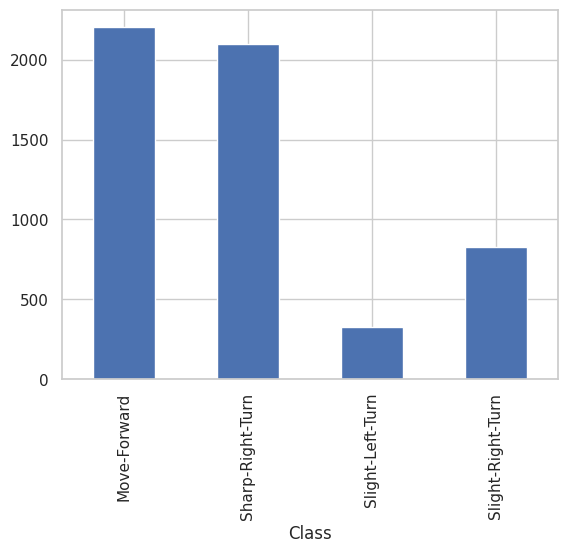

In [3]:
display(data_24_df.describe())
data_24_df.groupby("Class").size().plot(kind='bar')

print("Classe com mais amostras:", data_24_df["Class"].value_counts().idxmax(), "com", data_24_df["Class"].value_counts().max(), "amostras")
print("Classe com menos amostras:", data_24_df["Class"].value_counts().idxmin(), "com", data_24_df["Class"].value_counts().min(), "amostras")


### 3. Análise da Matriz de Covariância
Visualização da matriz de covariância para ambos os casos.

In [4]:
analizar_invertibilidade(data_24_df, "24 Sensores")

Análise de Invertibilidade: 24 Sensores
Global -> Posto: 24, Cond: 2.05e+01, RCond: 4.87e-02
Classe Move-Forward -> Posto: 24, Cond: 5.35e+01, RCond: 1.87e-02
Classe Sharp-Right-Turn -> Posto: 24, Cond: 3.13e+01, RCond: 3.20e-02
Classe Slight-Left-Turn -> Posto: 24, Cond: 1.73e+02, RCond: 5.77e-03
Classe Slight-Right-Turn -> Posto: 24, Cond: 1.96e+02, RCond: 5.10e-03
--------------------------------------------------


Os resultados indicam que todas as matrizes de covariância, global e por classe, possuem posto completo, igual à dimensão do vetor de atributos (p=24), logo, possui uma invertibilidade teórica. Já o número de condicionamento (Cond) e o RCond, mostram que as matrizes estão bem condicionadas numericamente, embora as classes de manobras suaves apresentem uma sensibilidade ligeiramente superior.

### 4. Visualização da Base de Dados com PCA


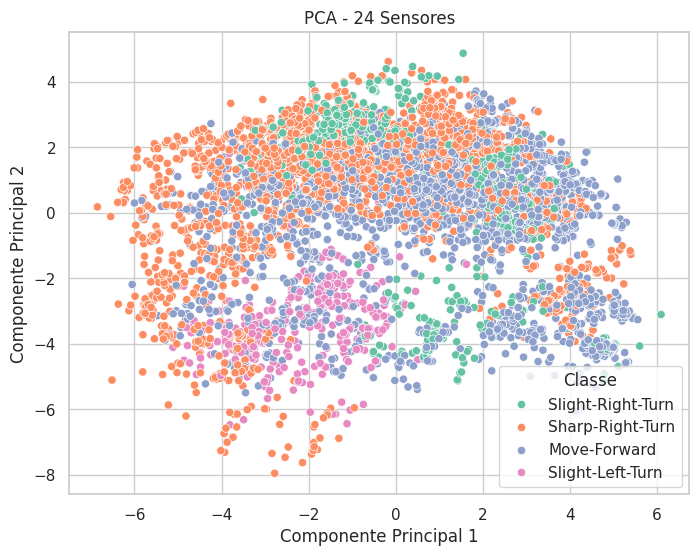

In [24]:
from classificao_padroes.models_trabalho3 import PCA

pca_24 = PCA()
X_24_pca = pca_24.fit(X_24)
X_24_pca = pca_24.transform(X_24)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_24_pca[:, 0], y=X_24_pca[:, 1], hue=data_24_df["Class"], palette='Set2')
plt.title("PCA - 24 Sensores")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Classe")
plt.show()



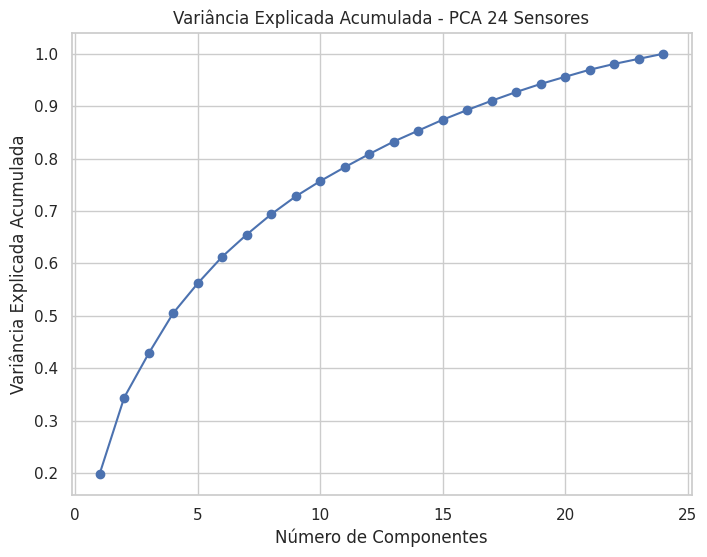

In [25]:
pca_cumsum = pca_24.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca_cumsum) + 1), pca_cumsum, marker='o')
plt.title("Variância Explicada Acumulada - PCA 24 Sensores")
plt.xlabel("Número de Componentes")
plt.ylabel("Variância Explicada Acumulada")
plt.grid(True)
plt.show()

### 5. Comparativo de Desempenho dos Modelos


In [27]:

from classificao_padroes.models_trabalho3 import ClassificadorDMP, ClassificadorQuadraticoGaussiano


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

X_train, X_test, y_train, y_test = train_test_split(X_24, data_24_df["Class"].values, test_size=0.2, random_state=42)

# le = LabelEncoder()
# y_train = le.fit_transform(y_train)
# y_test = le.transform(y_test)

In [28]:
N = data_24_df.groupby("Class").size().min()
print(f"Usando k_max = {int(np.sqrt(N))} para o classificador DMP.")

Usando k_max = 18 para o classificador DMP.


In [29]:
# Criando e treinando o classificador DMP
dmp_clf = ClassificadorDMP(k_min=2, k_max=int(np.sqrt(N)), n_runs=20)
dmp_clf.fit(X_train, y_train)
y_pred_dmp = dmp_clf.predict(X_test)
print("Relatório de Classificação - DMP:")
print(classification_report(y_test, y_pred_dmp))
print("Matriz de Confusão - DMP:")
print(confusion_matrix(y_test, y_pred_dmp))


Treinando DMP Multi-Protótipo. Classes: ['Move-Forward' 'Sharp-Right-Turn' 'Slight-Left-Turn' 'Slight-Right-Turn']
  Classe Move-Forward: Votos [DB=18, CH=2, Dunn=16] -> Escolhido: 18 (Desempate via DB)
  Classe Sharp-Right-Turn: Votos [DB=17, CH=2, Dunn=14] -> Escolhido: 17 (Desempate via DB)
  Classe Slight-Left-Turn: Votos [DB=18, CH=2, Dunn=16] -> Escolhido: 18 (Desempate via DB)
  Classe Slight-Right-Turn: Votos [DB=5, CH=4, Dunn=16] -> Escolhido: 5 (Desempate via DB)
Relatório de Classificação - DMP:
                   precision    recall  f1-score   support

     Move-Forward       0.78      0.70      0.73       454
 Sharp-Right-Turn       0.76      0.74      0.75       427
 Slight-Left-Turn       0.46      0.93      0.62        60
Slight-Right-Turn       0.59      0.57      0.58       151

         accuracy                           0.71      1092
        macro avg       0.65      0.74      0.67      1092
     weighted avg       0.73      0.71      0.71      1092

Matriz de Con

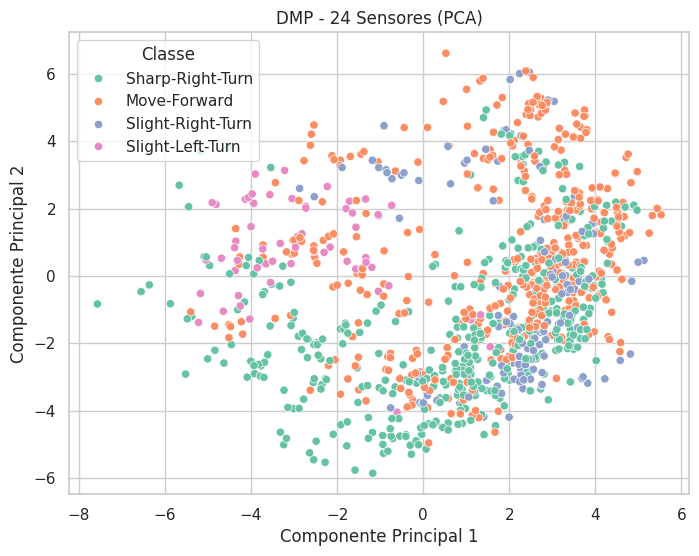

In [37]:
# Visualizando o plot do DMP para o dataset de 24 sensores (com PCA para reduzir para 2D)
prototipos_dmp = dmp_clf.all_prototypes_
pca_dmp = PCA()
pca_dmp.fit(prototipos_dmp)
X_test_dmp_pca = pca_dmp.transform(X_test)


plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_dmp_pca[:, 0], y=X_test_dmp_pca[:, 1], hue=y_test, palette='Set2')
plt.title("DMP - 24 Sensores (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Classe")
plt.show()

In [ ]:

# Criando e treinando o classificador QG
qg_clf = ClassificadorQuadraticoGaussiano()
qg_clf.fit(X_train, y_train)
y_pred_qg = qg_clf.predict(X_test)
print("Relatório de Classificação - QG:")
print(classification_report(y_test, y_pred_qg))
print("Matriz de Confusão - QG:")
print(confusion_matrix(y_test, y_pred_qg))

import matplotlib.pyplot as plt
import seaborn as sns

# Plot f1 score para DMP e QG
from sklearn.metrics import f1_score
f1_dmp = f1_score(y_test, y_pred_dmp, average='weighted')
f1_qg = f1_score(y_test, y_pred_qg, average='weighted')

# Create a DataFrame for seaborn
results_df = pd.DataFrame({'Classifier': ['DMP', 'QG'], 'F1 Score': [f1_dmp, f1_qg]})

plt.figure(figsize=(6, 4))
sns.barplot(data=results_df, x='Classifier', y='F1 Score', palette='viridis')
plt.title('F1 Score - DMP vs QG')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.show()

Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       454
           1       0.99      1.00      1.00       427
           2       1.00      0.95      0.97        60
           3       0.99      1.00      0.99       151

    accuracy                           0.99      1092
   macro avg       0.99      0.98      0.99      1092
weighted avg       0.99      0.99      0.99      1092

Matriz de Confusão - Random Forest:
[[449   3   0   2]
 [  0 427   0   0]
 [  2   1  57   0]
 [  0   0   0 151]]
Relatório de Classificação - KNN:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       454
           1       0.89      0.87      0.88       427
           2       0.91      0.83      0.87        60
           3       0.78      0.78      0.78       151

    accuracy                           0.85      1092
   macro avg       0.85      0.84      0.84     

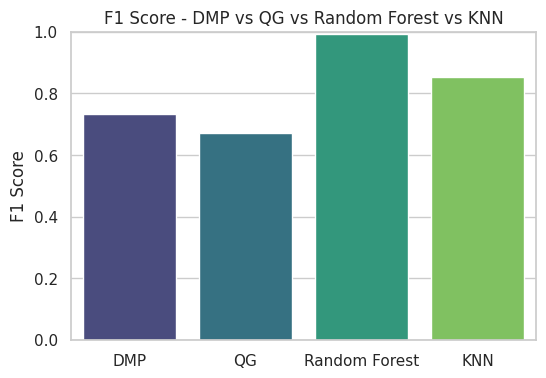

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print("Relatório de Classificação - Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("Matriz de Confusão - Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')
print("Relatório de Classificação - KNN:")
print(classification_report(y_test, y_pred_knn))
print("Matriz de Confusão - KNN:")
print(confusion_matrix(y_test, y_pred_knn))


plt.figure(figsize=(6, 4))
sns.barplot(x=['DMP', 'QG', 'Random Forest', 'KNN'], y=[f1_dmp, f1_qg, f1_rf, f1_knn], palette='viridis')
plt.title('F1 Score - DMP vs QG vs Random Forest vs KNN')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.show()

### Testando estatisticas sobre os resultados
- Agora testaremos se o calculo de covariancia do numpy e os metodos implementados, entre si, são estatisticamente diferentes, estamos interessados especialmente se `mcovar1` e `mcovar3` são estatisticamente diferentes. Assim como `mcovar4`e `NumPy Cov`.

In [9]:
from scipy.stats import mannwhitneyu
df_24_m1 = df_24[df_24['Método'] == 'mcovar1']
df_24_m2 = df_24[df_24['Método'] == 'mcovar2']
df_24_m3 = df_24[df_24['Método'] == 'mcovar3']
df_24_m4 = df_24[df_24['Método'] == 'mcovar4']
df_24_m5 = df_24[df_24['Método'] == 'NumPy Cov']

NameError: name 'df_24' is not defined

In [ ]:
stats, p = mannwhitneyu(df_24_m5['Tempo (ms)'], df_24_m4['Tempo (ms)'])
if p < 0.05:
    print("Existem diferenças significativas entre os métodos mcovar4 e Numpy Cov")
else:
    print("Não existem diferenças significativas entre os métodos")

Existem diferenças significativas entre os métodos mcovar4 e Numpy Cov


In [ ]:
stats, p = mannwhitneyu(df_24_m2['Tempo (ms)'], df_24_m4['Tempo (ms)'])
if p < 0.05:
    print("Existem diferenças significativas entre os métodos mcovar2 e mcovar4")
else:
    print("Não existem diferenças significativas entre os métodos")

Existem diferenças significativas entre os métodos mcovar2 e mcovar4


In [ ]:
stats, p = mannwhitneyu(df_24_m1['Tempo (ms)'], df_24_m3['Tempo (ms)'])
if p < 0.05:
    print("Existem diferenças significativas entre os métodos mcovar1 e mcovar3")
else:
    print("Não existem diferenças significativas entre os métodos")

Existem diferenças significativas entre os métodos mcovar1 e mcovar3


## Q3 - Avaliação da invertibilidade com base no metodo mais rapido.

In [ ]:
data_24_df.head()

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


In [ ]:
# Usando mcovar4 iremos estimar a matriz de covariancia de cada classe.
import numpy as np

def analyze_invertibility(df, label):
    print(f"Análise de Invertibilidade: {label}")
    X = df.drop(columns=['Class'])
    y = df['Class']
    
    # Matriz de Covariância Global
    cov_global = mcovar4(X)
    rank_g = np.linalg.matrix_rank(cov_global)
    cond_g = np.linalg.cond(cov_global)
    rcond_g = 1 / cond_g
    print(f"Global -> Posto: {rank_g}, Cond: {cond_g:.2e}, RCond: {rcond_g:.2e}")
    
    # Matrizes de Covariância por Classe
    for c in np.unique(y):
        X_c = X[y == c]
        cov_c = mcovar4(X_c)
        rank_c = np.linalg.matrix_rank(cov_c)
        cond_c = np.linalg.cond(cov_c)
        rcond_c = 1 / cond_c
        print(f"Classe {c} -> Posto: {rank_c}, Cond: {cond_c:.2e}, RCond: {rcond_c:.2e}")
    print("-" * 50)

analyze_invertibility(data_24_df, "data_24_df")
analyze_invertibility(data_4_df, "data_4_df")


Análise de Invertibilidade: data_24_df
Global -> Posto: 23, Cond: 4.61e+20, RCond: 2.17e-21
Classe Move-Forward -> Posto: 23, Cond: 3.39e+20, RCond: 2.95e-21
Classe Sharp-Right-Turn -> Posto: 23, Cond: 2.65e+20, RCond: 3.77e-21
Classe Slight-Left-Turn -> Posto: 23, Cond: 4.02e+19, RCond: 2.49e-20
Classe Slight-Right-Turn -> Posto: 23, Cond: 2.09e+20, RCond: 4.78e-21
--------------------------------------------------
Análise de Invertibilidade: data_4_df
Global -> Posto: 3, Cond: 5.14e+34, RCond: 1.94e-35
Classe Move-Forward -> Posto: 3, Cond: 6.19e+33, RCond: 1.62e-34
Classe Sharp-Right-Turn -> Posto: 3, Cond: 2.07e+34, RCond: 4.84e-35
Classe Slight-Left-Turn -> Posto: 3, Cond: 3.79e+18, RCond: 2.64e-19
Classe Slight-Right-Turn -> Posto: 3, Cond: 6.31e+34, RCond: 1.58e-35
--------------------------------------------------


### As matrizes acimas são singulares, não possuem posto completo. Assim, não podem ser invertidas e iremos regularizar.

In [ ]:
def reg_matriz(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adiciona regularização a uma matriz de covariância.
    """
    
    lamb = 0.1
    lambI = lamb * np.eye(df.shape[1])
    return df + lambI

In [ ]:
def inverter_reg(df, label):
    print(f"Análise de Invertibilidade: {label}")
    X = df.drop(columns=['Class'])
    y = df['Class']
    
    # Matriz de Covariância Global
    cov_global = mcovar4(X)

    cov_global = reg_matriz(cov_global)
    
    # Tentar inverter, se possivel, retornar mensagem de erro
    try:
        np.linalg.inv(cov_global)
        print("Global -> Invertível")
    except np.linalg.LinAlgError:
        print("Global -> Não Invertível")

    rank_g = np.linalg.matrix_rank(cov_global)
    cond_g = np.linalg.cond(cov_global)
    rcond_g = 1 / cond_g
    print(f"Global -> Posto: {rank_g}, Cond: {cond_g:.2e}, RCond: {rcond_g:.2e}")
    
    # Matrizes de Covariância por Classe
    for c in np.unique(y):
        X_c = X[y == c]
        cov_c = mcovar4(X_c)

        cov_c = reg_matriz(cov_c)

        try:
            np.linalg.inv(cov_c)
            print(f"Classe {c} -> Invertível")
        except np.linalg.LinAlgError:
            print(f"Classe {c} -> Não Invertível")
        
        rank_c = np.linalg.matrix_rank(cov_c)
        cond_c = np.linalg.cond(cov_c)
        rcond_c = 1 / cond_c
        print(f"Classe {c} -> Posto: {rank_c}, Cond: {cond_c:.2e}, RCond: {rcond_c:.2e}")
    print("-" * 50)

analyze_invertibility(data_24_df, "data_24_df")
analyze_invertibility(data_4_df, "data_4_df")

Análise de Invertibilidade: data_24_df
Global -> Posto: 23, Cond: 4.61e+20, RCond: 2.17e-21
Classe Move-Forward -> Posto: 23, Cond: 3.39e+20, RCond: 2.95e-21
Classe Sharp-Right-Turn -> Posto: 23, Cond: 2.65e+20, RCond: 3.77e-21
Classe Slight-Left-Turn -> Posto: 23, Cond: 4.02e+19, RCond: 2.49e-20
Classe Slight-Right-Turn -> Posto: 23, Cond: 2.09e+20, RCond: 4.78e-21
--------------------------------------------------
Análise de Invertibilidade: data_4_df
Global -> Posto: 3, Cond: 5.14e+34, RCond: 1.94e-35
Classe Move-Forward -> Posto: 3, Cond: 6.19e+33, RCond: 1.62e-34
Classe Sharp-Right-Turn -> Posto: 3, Cond: 2.07e+34, RCond: 4.84e-35
Classe Slight-Left-Turn -> Posto: 3, Cond: 3.79e+18, RCond: 2.64e-19
Classe Slight-Right-Turn -> Posto: 3, Cond: 6.31e+34, RCond: 1.58e-35
--------------------------------------------------
